# Multi-Model Evaluation & Comparison
**Hate Speech Detection — EN / NE / Code-Switched**

Evaluates 4 trained models with the same metrics pipeline used in training, then produces a side-by-side comparison dashboard.

| Model | Base Architecture | Epochs |
|-------|------------------|--------|
| DistilBERT (5 ep) | distilbert-base-multilingual-cased | 5 |
| MuRIL (9 ep) | google/muril-base-cased | 9 (interrupted before threshold save) |
| RoBERTa (10 ep) | xlm-roberta-base | 10 |
| RoBERTa (5 ep) | xlm-roberta-base | 5 |

| Step | Description |
|------|-------------|
| 1 | Install & import dependencies |
| 2 | Model registry (paths pre-filled) |
| 3 | Load val + test splits |
| 4 | Per-model: load → threshold tune/load → inference → metrics |
| 5 | Comparison dashboard (table, heatmap, radar, CMs, rankings) |
| 6 | Export `comparison_results.json` + `comparison_summary.csv` |

> **MuRIL note:** `thresholds.json` was not saved (training interrupted). The notebook automatically re-tunes thresholds on the val set and saves them to `/kaggle/working/` for future runs.

## 1 · Install & Imports

In [1]:
import subprocess, sys

for pkg in [
    "transformers", "datasets", "torch", "scikit-learn",
    "pandas", "numpy", "tqdm", "matplotlib", "sentencepiece",
    "seaborn", "requests", "ftfy"
]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("All packages ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 95.4 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.5 MB/s eta 0:00:00
All packages ready.


In [2]:
import os, json, random, warnings, re
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from tqdm.auto import tqdm
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

assert torch.cuda.is_available(), "Enable GPU: Settings → Accelerator → GPU T4"
DEVICE = torch.device("cuda")
print(f"Device: {DEVICE} ({torch.cuda.get_device_name(0)})")

WORK_DIR = "/kaggle/working"
LABELS   = ["clean", "profanity", "hate_speech", "threat", "identity_attack"]
print(f"Labels: {LABELS}")

Device: cuda (Tesla T4)
Labels: ['clean', 'profanity', 'hate_speech', 'threat', 'identity_attack']


## 2 · Model Registry

Edit the four entries below — set `path` to the saved checkpoint directory and give each model a short display `name`.


In [3]:
# ──────────────────────────────────────────────────────────────────
#  MODEL REGISTRY — all 4 models, real Kaggle paths
#
#  thresholds_path:
#    • Point to a saved thresholds.json to skip val-set tuning.
#    • Set to None to run threshold tuning on the fly (required for
#      MuRIL because training was interrupted before the file was saved).
# ──────────────────────────────────────────────────────────────────
MODEL_REGISTRY = [
    {
        "name":            "DistilBERT (5 ep)",
        "path":            "/kaggle/input/models/hridayanshu23/distilbert-hatespeech/transformers/default/1",
        "color":           "#3498db",
        "epochs_trained":  5,
        # DistilBERT checkpoint — update path if thresholds.json was saved alongside it
        "thresholds_path": "/kaggle/input/models/hridayanshu23/distilbert-hatespeech/transformers/default/1/thresholds.json",
    },
    {
        "name":            "MuRIL (9 ep)",
        "path":            "/kaggle/input/models/hridayanshu23/muril-hate-speech/transformers/default/1",
        "color":           "#e74c3c",
        "epochs_trained":  9,
        # Training was interrupted before thresholds.json was written → re-tune from val set
        "thresholds_path": None,
    },
    {
        "name":            "RoBERTa (10 ep)",
        "path":            "/kaggle/input/models/hridayanshu23/roberta-hatespeech-10-epochs/transformers/default/1",
        "color":           "#2ecc71",
        "epochs_trained":  10,
        "thresholds_path": "/kaggle/input/models/hridayanshu23/roberta-hatespeech-10-epochs/transformers/default/1/thresholds.json",
    },
    {
        "name":            "RoBERTa (5 ep)",
        "path":            "/kaggle/input/models/hridayanshu23/roberta-hatespeech-5-epoch/transformers/default/1",
        "color":           "#f39c12",
        "epochs_trained":  5,
        "thresholds_path": "/kaggle/input/models/hridayanshu23/roberta-hatespeech-5-epoch/transformers/default/1/thresholds.json",
    },
]

# Inference batch size — reduce to 16 if you hit GPU OOM
BATCH_SIZE     = 32
MAX_LENGTH     = 128
THRESHOLD_GRID = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65]

print("Models to evaluate:")
for m in MODEL_REGISTRY:
    thresh_note = "will re-tune" if m["thresholds_path"] is None else "has thresholds.json"
    print(f"  {m['name']:<22} | {m['epochs_trained']} epochs | {thresh_note}")

Models to evaluate:
  DistilBERT (5 ep)      | 5 epochs | has thresholds.json
  MuRIL (9 ep)           | 9 epochs | will re-tune
  RoBERTa (10 ep)        | 10 epochs | has thresholds.json
  RoBERTa (5 ep)         | 5 epochs | has thresholds.json


## 3 · Dataset

In [4]:
DATA_DIR = "/kaggle/input/datasets/hridayanshu23/hate-speech-en-ne"

val_df  = pd.read_csv(os.path.join(DATA_DIR, "val_split.csv" )).reset_index(drop=True)
test_df = pd.read_csv(os.path.join(DATA_DIR, "test_split.csv")).reset_index(drop=True)

print("Dataset summary:")
for name, df in [("Val", val_df), ("Test", test_df)]:
    en = (df["language"]=="en").sum() if "language" in df.columns else "N/A"
    ne = (df["language"]=="ne").sum() if "language" in df.columns else "N/A"
    cs = (df["language"]=="cs").sum() if "language" in df.columns else "N/A"
    hs = df["hate_speech"].sum()
    print(f"  {name}: {len(df):6,} | EN={en} NE={ne} CS={cs} | "
          f"hate_speech={hs:,} ({100*hs/len(df):.1f}%)")


class HateSpeechDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.texts     = df["text"].tolist()
        self.labels    = df[LABELS].values.astype(np.float32)
        self.languages = df["language"].tolist() if "language" in df.columns else ["en"]*len(df)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], max_length=self.max_length,
            padding="max_length", truncation=True, return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.float),
            "language":       self.languages[idx],
        }

Dataset summary:
  Val: 20,684 | EN=17587 NE=2902 CS=195 | hate_speech=2,842 (13.7%)
  Test: 20,685 | EN=17688 NE=2804 CS=193 | hate_speech=2,842 (13.7%)


## 4 · Evaluation Loop

For each model:
1. Load model + tokenizer
2. Run inference on val set → tune per-language thresholds
3. Run inference on test set → apply thresholds → compute all metrics
4. Collect results in `all_results`

In [5]:
def run_inference(model, loader, device):
    """Return (logits_np, labels_np, langs_list)"""
    model.eval()
    all_logits, all_labels, all_langs = [], [], []
    with torch.no_grad():
        for batch in tqdm(loader, leave=False):
            ids  = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            out  = model(input_ids=ids, attention_mask=mask)
            all_logits.append(out.logits.cpu().numpy())
            all_labels.append(batch["labels"].numpy())
            all_langs.extend(batch["language"])
    return (np.concatenate(all_logits),
            np.concatenate(all_labels),
            np.array(all_langs))


def tune_thresholds(probs, labels, langs, grid=THRESHOLD_GRID):
    """Return dict {lang: best_threshold}"""
    thresholds = {}
    for lang in ["en", "ne", "cs"]:
        mask = langs == lang
        if mask.sum() < 10:
            thresholds[lang] = 0.5
            continue
        best_f1, best_t = 0.0, 0.5
        for t in grid:
            preds = (probs[mask] >= t).astype(int)
            f1    = f1_score(labels[mask], preds, average="macro", zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        thresholds[lang] = best_t
    return thresholds


def apply_thresholds(probs, langs, thresholds, default=0.5):
    preds = np.zeros_like(probs, dtype=int)
    for lang, thresh in thresholds.items():
        mask = langs == lang
        if mask.sum() > 0:
            preds[mask] = (probs[mask] >= thresh).astype(int)
    unlabeled = ~np.isin(langs, list(thresholds.keys()))
    preds[unlabeled] = (probs[unlabeled] >= default).astype(int)
    return preds


def compute_metrics(labels_arr, preds_arr, langs_arr, thresholds):
    """Return a structured metrics dict matching the training notebook format."""
    macro_f1    = f1_score(labels_arr, preds_arr, average="macro",    zero_division=0)
    weighted_f1 = f1_score(labels_arr, preds_arr, average="weighted", zero_division=0)
    accuracy    = accuracy_score(labels_arr.flatten(), preds_arr.flatten())
    per_class   = f1_score(labels_arr, preds_arr, average=None, zero_division=0).tolist()

    lang_results = {}
    for lang, lang_name in [("en","English"),("ne","Nepali"),("cs","Code-switched")]:
        mask = langs_arr == lang
        if mask.sum() == 0:
            continue
        l_true = labels_arr[mask]; l_pred = preds_arr[mask]
        lang_results[lang_name] = {
            "macro_f1":  float(f1_score(l_true, l_pred, average="macro",    zero_division=0)),
            "accuracy":  float(accuracy_score(l_true.flatten(), l_pred.flatten())),
            "threshold": float(thresholds.get(lang, 0.5)),
            "per_class": dict(zip(LABELS, f1_score(l_true, l_pred, average=None, zero_division=0).tolist())),
            "n_samples": int(mask.sum()),
        }

    return {
        "overall_macro_f1":    float(macro_f1),
        "overall_weighted_f1": float(weighted_f1),
        "overall_accuracy":    float(accuracy),
        "per_class_f1":        dict(zip(LABELS, per_class)),
        "thresholds":          thresholds,
        "language_results":    lang_results,
    }

print("Helper functions defined.")

Helper functions defined.


In [6]:
all_results   = []   # will hold one dict per model
all_preds     = {}   # name → preds array  (for confusion matrices later)
all_labels_np = None # shared ground truth
all_langs_np  = None

for cfg in MODEL_REGISTRY:
    mname = cfg["name"]
    mpath = cfg["path"]

    print("\n" + "="*70)
    print(f"  MODEL: {mname}  |  {mpath}")
    print("="*70)

    # ── Load model & tokenizer ─────────────────────────────────────────
    tokenizer = AutoTokenizer.from_pretrained(mpath)
    model     = AutoModelForSequenceClassification.from_pretrained(
        mpath, num_labels=5, problem_type="multi_label_classification"
    ).to(DEVICE)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"  Parameters: {total_params:,}")

    # ── Dataloaders (tokenizer-specific) ──────────────────────────────
    val_loader  = DataLoader(HateSpeechDataset(val_df,  tokenizer, MAX_LENGTH),
                             batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(HateSpeechDataset(test_df, tokenizer, MAX_LENGTH),
                             batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    # ── Threshold loading / tuning (val set) ─────────────────────────
    tpath = cfg.get("thresholds_path")
    if tpath and os.path.exists(tpath):
        with open(tpath) as f:
            thresholds = json.load(f)
        print(f"  Thresholds loaded from file: {thresholds}")
    else:
        if tpath and not os.path.exists(tpath):
            print(f"  ⚠  thresholds.json not found at:\n     {tpath}")
            print("  → Re-tuning from validation set instead.")
        else:
            print("  Tuning per-language thresholds on validation set...")
        val_logits, val_labels_np_t, val_langs_np_t = run_inference(model, val_loader, DEVICE)
        val_probs  = torch.sigmoid(torch.tensor(val_logits)).numpy()
        thresholds = tune_thresholds(val_probs, val_labels_np_t, val_langs_np_t)
        # Save tuned thresholds for future runs
        thresh_save = os.path.join(WORK_DIR, f"thresholds_{mname.replace(' ', '_').replace('(','').replace(')','')}.json")
        with open(thresh_save, "w") as f:
            json.dump(thresholds, f, indent=2)
        print(f"  Thresholds tuned & saved → {thresh_save}")
        print(f"  {thresholds}")

    # ── Test set inference ────────────────────────────────────────────
    print("  Running test set inference...")
    test_logits, test_labels_np, test_langs_np = run_inference(model, test_loader, DEVICE)
    test_probs = torch.sigmoid(torch.tensor(test_logits)).numpy()
    test_preds = apply_thresholds(test_probs, test_langs_np, thresholds)

    # ── Metrics ───────────────────────────────────────────────────────
    metrics = compute_metrics(test_labels_np, test_preds, test_langs_np, thresholds)

    # Pretty-print (same format as training notebook)
    print("\n" + classification_report(test_labels_np, test_preds,
                                       target_names=LABELS, zero_division=0))
    print(f"  Overall Accuracy:    {metrics['overall_accuracy']:.4f}")
    print(f"  Overall Macro F1:    {metrics['overall_macro_f1']:.4f}")
    print(f"  Overall Weighted F1: {metrics['overall_weighted_f1']:.4f}")
    print("\n  Per-language breakdown:")
    for lname, lres in metrics["language_results"].items():
        print(f"    {lname} ({lres['n_samples']} samples | threshold={lres['threshold']:.2f}):")
        print(f"      Accuracy: {lres['accuracy']:.4f} | Macro F1: {lres['macro_f1']:.4f}")
        for lbl, f1v in lres["per_class"].items():
            print(f"        {lbl:20s}: F1={f1v:.4f}")

    # ── Store ─────────────────────────────────────────────────────────
    all_results.append({
        "name":           mname,
        "color":          cfg["color"],
        "n_params":       total_params,
        "epochs_trained": cfg.get("epochs_trained", "?"),
        **metrics
    })
    all_preds[mname] = test_preds
    if all_labels_np is None:
        all_labels_np = test_labels_np
        all_langs_np  = test_langs_np

    # Free GPU memory before next model
    del model
    torch.cuda.empty_cache()

print("\n" + "="*70)
print("  ALL MODELS EVALUATED")
print("="*70)


  MODEL: DistilBERT (5 ep)  |  /kaggle/input/models/hridayanshu23/distilbert-hatespeech/transformers/default/1


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  Parameters: 135,328,517
  Thresholds loaded from file: {'en': 0.65, 'ne': 0.4, 'cs': 0.4}
  Running test set inference...


  0%|          | 0/647 [00:00<?, ?it/s]


                 precision    recall  f1-score   support

          clean       0.97      0.94      0.96     17751
      profanity       0.71      0.88      0.79       952
    hate_speech       0.75      0.81      0.78      2842
         threat       0.54      0.69      0.61       444
identity_attack       0.55      0.72      0.62       444

      micro avg       0.91      0.92      0.91     22433
      macro avg       0.71      0.81      0.75     22433
   weighted avg       0.92      0.92      0.92     22433
    samples avg       0.91      0.92      0.91     22433

  Overall Accuracy:    0.9615
  Overall Macro F1:    0.7518
  Overall Weighted F1: 0.9153

  Per-language breakdown:
    English (17688 samples | threshold=0.65):
      Accuracy: 0.9616 | Macro F1: 0.7552
        clean               : F1=0.9604
        profanity           : F1=0.7820
        hate_speech         : F1=0.7889
        threat              : F1=0.6170
        identity_attack     : F1=0.6277
    Nepali (2804 samp

...


                 precision    recall  f1-score   support

          clean       0.97      0.96      0.97     17751
      profanity       0.72      0.90      0.80       952
    hate_speech       0.79      0.82      0.80      2842
         threat       0.59      0.71      0.65       444
identity_attack       0.60      0.76      0.67       444

      micro avg       0.92      0.93      0.92     22433
      macro avg       0.73      0.83      0.78     22433
   weighted avg       0.92      0.93      0.93     22433
    samples avg       0.93      0.93      0.93     22433

  Overall Accuracy:    0.9672
  Overall Macro F1:    0.7770
  Overall Weighted F1: 0.9272

  Per-language breakdown:
    English (17688 samples | threshold=0.60):
      Accuracy: 0.9681 | Macro F1: 0.7806
        clean               : F1=0.9704
        profanity           : F1=0.7970
        hate_speech         : F1=0.8165
        threat              : F1=0.6491
        identity_attack     : F1=0.6700
    Nepali (2804 samp

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Parameters: 278,047,493
  Thresholds loaded from file: {'en': 0.65, 'ne': 0.35, 'cs': 0.3}
  Running test set inference...


  0%|          | 0/647 [00:00<?, ?it/s]


                 precision    recall  f1-score   support

          clean       0.97      0.95      0.96     17751
      profanity       0.68      0.90      0.78       952
    hate_speech       0.78      0.81      0.80      2842
         threat       0.59      0.65      0.62       444
identity_attack       0.60      0.74      0.66       444

      micro avg       0.92      0.92      0.92     22433
      macro avg       0.73      0.81      0.76     22433
   weighted avg       0.92      0.92      0.92     22433
    samples avg       0.92      0.93      0.92     22433

  Overall Accuracy:    0.9649
  Overall Macro F1:    0.7632
  Overall Weighted F1: 0.9219

  Per-language breakdown:
    English (17688 samples | threshold=0.65):
      Accuracy: 0.9652 | Macro F1: 0.7639
        clean               : F1=0.9663
        profanity           : F1=0.7749
        hate_speech         : F1=0.8016
        threat              : F1=0.6140
        identity_attack     : F1=0.6626
    Nepali (2804 samp

## 5 · Comparison Dashboard

### 5a · Summary Table

In [7]:
rows = []
for r in all_results:
    row = {
        "Model":        r["name"],
        "Epochs":       r.get("epochs_trained", "?"),
        "Params (M)":  f"{r['n_params']/1e6:.1f}",
        "Accuracy":    f"{r['overall_accuracy']:.4f}",
        "Macro F1":    f"{r['overall_macro_f1']:.4f}",
        "Weighted F1": f"{r['overall_weighted_f1']:.4f}",
    }
    for lang_name in ["English", "Nepali", "Code-switched"]:
        lres = r["language_results"].get(lang_name, {})
        row[f"{lang_name} F1"] = f"{lres.get('macro_f1', 0):.4f}" if lres else "N/A"
    rows.append(row)

summary_df = pd.DataFrame(rows)
print("\n" + "="*80)
print("  SUMMARY COMPARISON TABLE")
print("="*80)
print(summary_df.to_string(index=False))


  SUMMARY COMPARISON TABLE
            Model  Epochs Params (M) Accuracy Macro F1 Weighted F1 English F1 Nepali F1 Code-switched F1
DistilBERT (5 ep)       5      135.3   0.9615   0.7518      0.9153     0.7552    0.6445           0.5815
     MuRIL (9 ep)       9      237.6   0.9653   0.7583      0.9207     0.7611    0.6887           0.5849
  RoBERTa (10 ep)      10      278.0   0.9672   0.7770      0.9272     0.7806    0.7131           0.6000
   RoBERTa (5 ep)       5      278.0   0.9649   0.7632      0.9219     0.7639    0.7361           0.5820


### 5b · Overall Metrics — Bar Charts

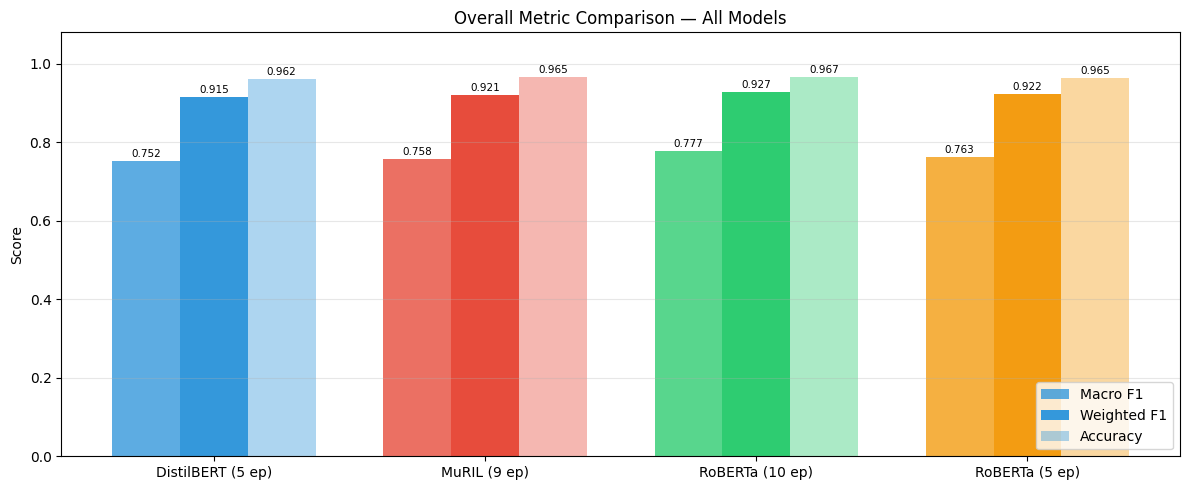

In [8]:
names  = [r["name"]  for r in all_results]
colors = [r["color"] for r in all_results]
x      = np.arange(len(names))
width  = 0.25

macro_f1s    = [r["overall_macro_f1"]    for r in all_results]
weighted_f1s = [r["overall_weighted_f1"] for r in all_results]
accs         = [r["overall_accuracy"]    for r in all_results]

fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - width, macro_f1s,    width, label="Macro F1",    color=[c + "cc" for c in colors])
b2 = ax.bar(x,          weighted_f1s, width, label="Weighted F1", color=colors)
b3 = ax.bar(x + width,  accs,         width, label="Accuracy",    color=[c + "66" for c in colors])

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f"{h:.3f}", ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylim(0, 1.08); ax.set_ylabel("Score")
ax.set_title("Overall Metric Comparison — All Models")
ax.legend(loc="lower right"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "compare_overall.png"), dpi=100, bbox_inches="tight")
plt.show()

### 5c · Per-Class F1 Heatmap

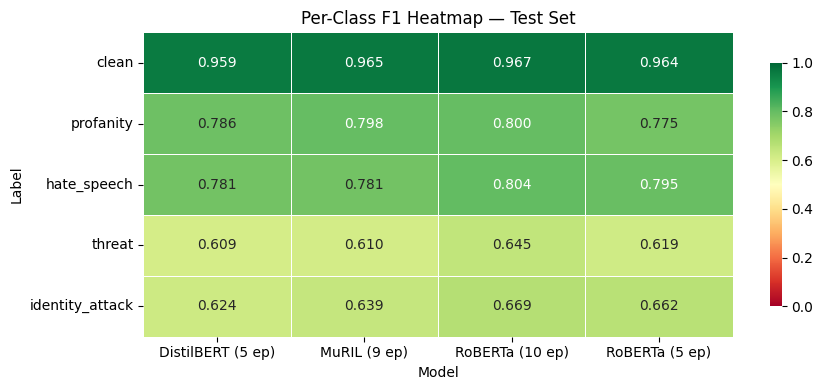

In [9]:
heatmap_data = pd.DataFrame(
    {r["name"]: [r["per_class_f1"][lbl] for lbl in LABELS] for r in all_results},
    index=LABELS
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    heatmap_data, annot=True, fmt=".3f", cmap="RdYlGn",
    vmin=0, vmax=1, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8}
)
ax.set_title("Per-Class F1 Heatmap — Test Set")
ax.set_xlabel("Model"); ax.set_ylabel("Label")
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "compare_perclass_heatmap.png"), dpi=100, bbox_inches="tight")
plt.show()

### 5d · Per-Language Macro F1 — Grouped Bar

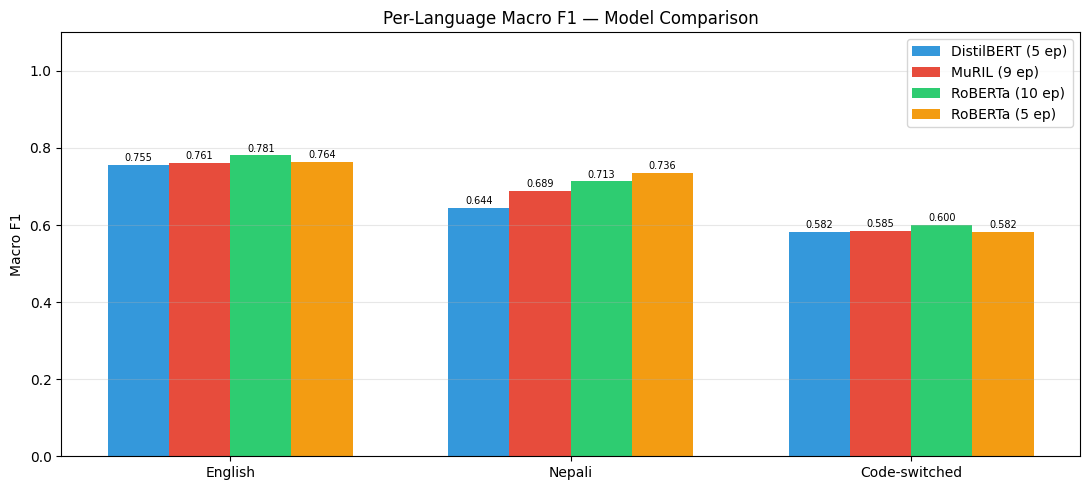

In [10]:
lang_names = ["English", "Nepali", "Code-switched"]
n_langs    = len(lang_names)
n_models   = len(all_results)
bar_width  = 0.18
x_lang     = np.arange(n_langs)

fig, ax = plt.subplots(figsize=(11, 5))
for i, r in enumerate(all_results):
    vals = [
        r["language_results"].get(ln, {}).get("macro_f1", 0)
        for ln in lang_names
    ]
    offset = (i - n_models / 2 + 0.5) * bar_width
    bars = ax.bar(x_lang + offset, vals, bar_width, label=r["name"], color=r["color"])
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                f"{v:.3f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x_lang); ax.set_xticklabels(lang_names)
ax.set_ylim(0, 1.1); ax.set_ylabel("Macro F1")
ax.set_title("Per-Language Macro F1 — Model Comparison")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "compare_per_language.png"), dpi=100, bbox_inches="tight")
plt.show()

### 5e · Per-Class F1 Grouped Bar (one subplot per class)

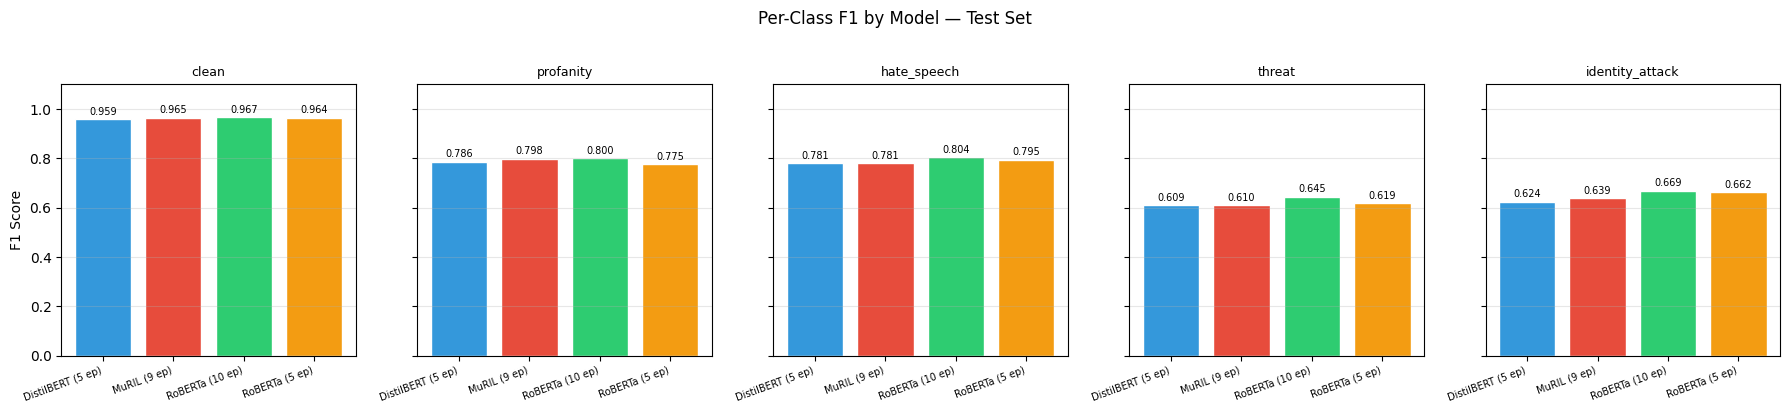

In [11]:
fig, axes = plt.subplots(1, len(LABELS), figsize=(18, 4), sharey=True)
x_models  = np.arange(len(all_results))

for ax, lbl in zip(axes, LABELS):
    vals   = [r["per_class_f1"][lbl] for r in all_results]
    colors = [r["color"] for r in all_results]
    bars   = ax.bar(x_models, vals, color=colors, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                f"{v:.3f}", ha="center", va="bottom", fontsize=7)
    ax.set_title(lbl, fontsize=9)
    ax.set_xticks(x_models)
    ax.set_xticklabels([r["name"] for r in all_results], rotation=20, ha="right", fontsize=7)
    ax.set_ylim(0, 1.1)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("F1 Score")
fig.suptitle("Per-Class F1 by Model — Test Set", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "compare_perclass_bars.png"), dpi=100, bbox_inches="tight")
plt.show()

### 5f · Radar / Spider Chart

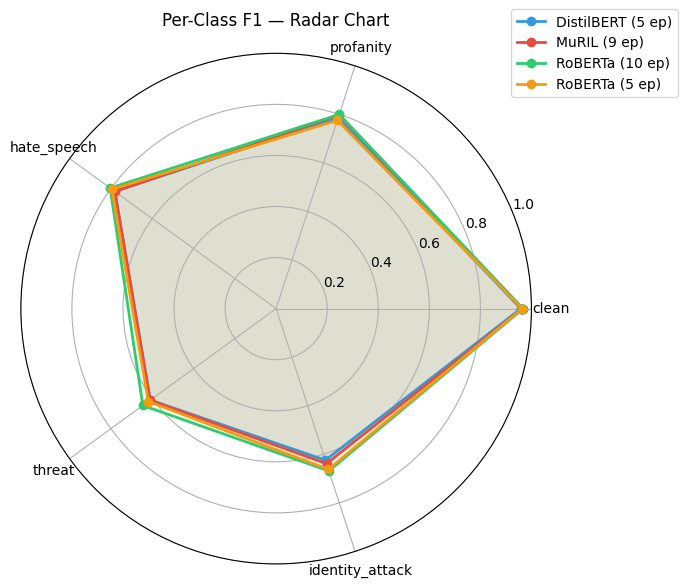

In [12]:
# Axes: 5 per-class F1 scores
N_axes    = len(LABELS)
angles    = np.linspace(0, 2*np.pi, N_axes, endpoint=False).tolist()
angles   += angles[:1]   # close the polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for r in all_results:
    vals  = [r["per_class_f1"][lbl] for lbl in LABELS]
    vals += vals[:1]
    ax.plot(angles, vals, "o-", linewidth=2, label=r["name"], color=r["color"])
    ax.fill(angles, vals, alpha=0.08, color=r["color"])

ax.set_thetagrids(np.degrees(angles[:-1]), LABELS)
ax.set_ylim(0, 1)
ax.set_title("Per-Class F1 — Radar Chart", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "compare_radar.png"), dpi=100, bbox_inches="tight")
plt.show()

### 5g · Confusion Matrices (hate_speech class, all models)

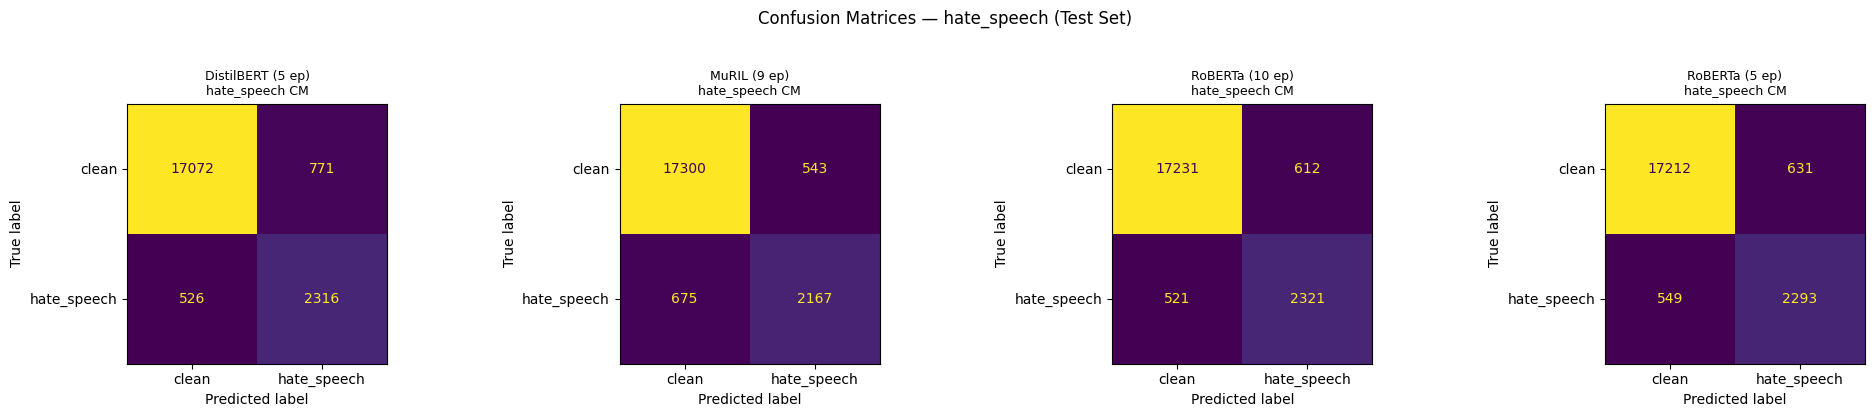

In [13]:
hs_idx   = LABELS.index("hate_speech")
hs_true  = all_labels_np[:, hs_idx].astype(int)
n_models = len(all_results)

fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 4))
if n_models == 1: axes = [axes]

for ax, r in zip(axes, all_results):
    hs_pred = all_preds[r["name"]][:, hs_idx]
    cm      = confusion_matrix(hs_true, hs_pred)
    disp    = ConfusionMatrixDisplay(cm, display_labels=["clean", "hate_speech"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"{r['name']}\nhate_speech CM", fontsize=9)

plt.suptitle("Confusion Matrices — hate_speech (Test Set)", y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "compare_confusion_matrices.png"), dpi=100, bbox_inches="tight")
plt.show()

### 5h · Ranked Summary — Best Model per Metric

In [14]:
metrics_to_rank = [
    ("overall_macro_f1",    "Overall Macro F1"),
    ("overall_weighted_f1", "Overall Weighted F1"),
    ("overall_accuracy",    "Overall Accuracy"),
]

for lang_name in ["English", "Nepali", "Code-switched"]:
    metrics_to_rank.append((f"lang_{lang_name}", f"{lang_name} Macro F1"))

print("\n" + "="*55)
print("  RANKINGS — Best Model per Metric")
print("="*55)

for key, label in metrics_to_rank:
    if key.startswith("lang_"):
        lname = key[5:]
        scores = [(r["name"], r["language_results"].get(lname, {}).get("macro_f1", 0))
                  for r in all_results]
    else:
        scores = [(r["name"], r[key]) for r in all_results]

    ranked = sorted(scores, key=lambda x: x[1], reverse=True)
    best_name, best_val = ranked[0]
    print(f"  {label:<25} → {best_name} ({best_val:.4f})")
    for rank, (name, val) in enumerate(ranked, 1):
        marker = "★" if rank == 1 else f" {rank}"
        print(f"      {marker}  {name:<20} {val:.4f}")


  RANKINGS — Best Model per Metric
  Overall Macro F1          → RoBERTa (10 ep) (0.7770)
      ★  RoBERTa (10 ep)      0.7770
       2  RoBERTa (5 ep)       0.7632
       3  MuRIL (9 ep)         0.7583
       4  DistilBERT (5 ep)    0.7518
  Overall Weighted F1       → RoBERTa (10 ep) (0.9272)
      ★  RoBERTa (10 ep)      0.9272
       2  RoBERTa (5 ep)       0.9219
       3  MuRIL (9 ep)         0.9207
       4  DistilBERT (5 ep)    0.9153
  Overall Accuracy          → RoBERTa (10 ep) (0.9672)
      ★  RoBERTa (10 ep)      0.9672
       2  MuRIL (9 ep)         0.9653
       3  RoBERTa (5 ep)       0.9649
       4  DistilBERT (5 ep)    0.9615
  English Macro F1          → RoBERTa (10 ep) (0.7806)
      ★  RoBERTa (10 ep)      0.7806
       2  RoBERTa (5 ep)       0.7639
       3  MuRIL (9 ep)         0.7611
       4  DistilBERT (5 ep)    0.7552
  Nepali Macro F1           → RoBERTa (5 ep) (0.7361)
      ★  RoBERTa (5 ep)       0.7361
       2  RoBERTa (10 ep)      0.7131
       3  M

## 6 · Export Results

In [15]:
out_path = os.path.join(WORK_DIR, "comparison_results.json")
with open(out_path, "w") as f:
    json.dump(all_results, f, indent=2)

csv_path = os.path.join(WORK_DIR, "comparison_summary.csv")
summary_df.to_csv(csv_path, index=False)

print(f"Full results  → {out_path}")
print(f"Summary table → {csv_path}")
print("\nPlots saved:")
for fname in [
    "compare_overall.png",
    "compare_perclass_heatmap.png",
    "compare_per_language.png",
    "compare_perclass_bars.png",
    "compare_radar.png",
    "compare_confusion_matrices.png",
]:
    p = os.path.join(WORK_DIR, fname)
    if os.path.exists(p):
        print(f"  ✓ {fname}")

Full results  → /kaggle/working/comparison_results.json
Summary table → /kaggle/working/comparison_summary.csv

Plots saved:
  ✓ compare_overall.png
  ✓ compare_perclass_heatmap.png
  ✓ compare_per_language.png
  ✓ compare_perclass_bars.png
  ✓ compare_radar.png
  ✓ compare_confusion_matrices.png
